In [16]:
from astroquery.gaia import Gaia

In [18]:
query = """
SELECT
    gaia.source_id, gaia.ra, gaia.dec, gaia.phot_g_mean_mag, gaia.bp_rp, gaia.parallax,
    tmass.j_m, tmass.h_m, tmass.ks_m, tmass.ph_qual
FROM gaiadr3.gaia_source AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    ON gaia.source_id = xmatch.source_id
JOIN gaiadr1.tmass_original_valid AS tmass
    ON xmatch.original_ext_source_id = tmass.designation
WHERE
    DISTANCE(POINT('ICRS', gaia.ra, gaia.dec), POINT('ICRS', 132.825, 11.8)) < 1
    AND gaia.phot_g_mean_mag < 14
"""

job = Gaia.launch_job_async(query)
results = job.get_results()
print(len(results))


INFO: Query finished. [astroquery.utils.tap.core]
1018


In Text cell above is the query to search gaiadr3 - the distance point is based off of the M67 cluster as requested in the assignment, and the mean magnitude less than 14
The number of stars returned is 1018.

In [20]:
cuts = (results['ph_qual'] == 'AAA') & (results['parallax'] > 0)
cut_results = results[cuts]
print(len(cut_results))

988


The cell above cuts all ph_qual that does not satisfy the requirements of AAA and all the stars where the parallax is less than or equal to 0. This tells us there at 988 stars left.

In [22]:
import numpy as np

In [23]:
distance_pc = 1000/cut_results['parallax'] #doing this to convert parallax to distance so we can get absolute magnitude

In [29]:
abs_g_mag = cut_results['phot_g_mean_mag'] - 5*np.log10(distance_pc) + 5

In [30]:
import matplotlib.pyplot as plt

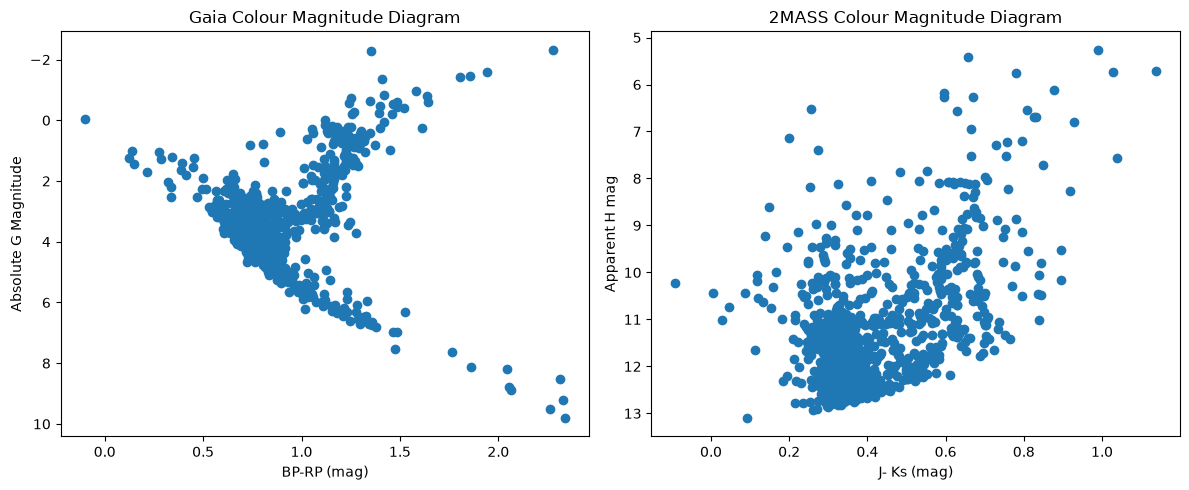

In [31]:
fig,axes = plt.subplots(1,2, figsize = (12, 5))

#gaia colour mag diagram - panel 1
axes[0].scatter(cut_results['bp_rp'], abs_g_mag)
axes[0].invert_yaxis()
axes[0].set_xlabel('BP-RP (mag)')
axes[0].set_ylabel('Absolute G Magnitude')
axes[0].set_title('Gaia Colour Magnitude Diagram')

#2MASS colour mag diagram - panel 2
j_minus_ks = cut_results['j_m'] - cut_results['ks_m']
axes[1].scatter(j_minus_ks, cut_results['h_m'])
axes[1].invert_yaxis()
axes[1].set_xlabel('J- Ks (mag)')
axes[1].set_ylabel('Apparent H mag')
axes[1].set_title('2MASS Colour Magnitude Diagram')

plt.tight_layout()
plt.show()

The two plots above show the two different colour magnitude diagrams, the 2MASS diagram shows more scatter than the GAIA diagram, likely due to different effects from the different filter bands.